In [59]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
employee = pd.read_csv("C:\\Users\\ANSHUMAN RAI\\OneDrive\\Desktop\\Employee Model\\Data\\enterprise_employee_dataset.csv")

In [60]:
employee.head()

,employee_id,age,department,role,region,education_level,years_worked,attendance_percent,training_hours,promotions,tasks_completed,project_success_rate,manager_rating,peer_rating,salary,performance_score
0,10000,50,IT,Senior,North,Bachelor,27,95.979475,41.126367,4,477.644408,1.0,5.000000,4.716953,114859.816909,4.96
1,10001,36,Sales,Junior,West,Bachelor,12,89.864621,60.466817,2,230.704433,1.0,4.696932,5.000000,51774.658730,4.54
2,10002,29,IT,Manager,North,Bachelor,8,91.401456,42.803520,1,193.453908,1.0,5.000000,5.000000,114997.437618,4.38
3,10003,42,IT,Junior,South,PhD,19,86.652088,75.414572,3,422.283484,1.0,4.651028,5.000000,61916.153745,4.78
4,10004,40,IT,Junior,West,Master,19,91.950536,51.439151,3,401.565903,1.0,5.000000,5.000000,72385.943688,4.76


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
scaler = MinMaxScaler()

employee[["years_norm"]] = scaler.fit_transform(employee[["years_worked"]])
employee[["attendance_norm"]] = scaler.fit_transform(employee[["attendance_percent"]])
employee[["training_norm"]] = scaler.fit_transform(employee[["training_hours"]])
employee[["promotion_norm"]] = scaler.fit_transform(employee[["promotions"]])

employee["performance_score"] = (
    0.35 * employee["attendance_norm"] +
    0.25 * employee["years_norm"] +
    0.20 * employee["training_norm"] +
    0.20 * employee["promotion_norm"]
)

employee["performance_score"] = 1 + employee["performance_score"] * 4

print(employee.head())

   employee_id  age department     role region education_level  years_worked  \
0        10000   50         IT   Senior  North        Bachelor            27   
1        10001   36      Sales   Junior   West        Bachelor            12   
2        10002   29         IT  Manager  North        Bachelor             8   
3        10003   42         IT   Junior  South             PhD            19   
4        10004   40         IT   Junior   West          Master            19   

   attendance_percent  training_hours  promotions  tasks_completed  \
0           95.979475       41.126367           4       477.644408   
1           89.864621       60.466817           2       230.704433   
2           91.401456       42.803520           1       193.453908   
3           86.652088       75.414572           3       422.283484   
4           91.950536       51.439151           3       401.565903   

   project_success_rate  manager_rating  peer_rating         salary  \
0                   1.0    

In [62]:
department = LabelEncoder()
role = LabelEncoder()

employee["department"] = department.fit_transform(employee["department"])
employee["role"] = role.fit_transform(employee["role"])

In [65]:
features = [
    "age",
    "years_worked",
    "attendance_percent",
    "training_hours",
    "promotions",
    "projects_completed",
    "manager_rating",
    "peer_rating",
    "salary"
]

In [66]:
employee.head()

,employee_id,age,department,role,region,education_level,years_worked,attendance_percent,training_hours,promotions,tasks_completed,project_success_rate,manager_rating,peer_rating,salary,performance_score,years_norm,attendance_norm,training_norm,promotion_norm
0,10000,50,2,3,North,Bachelor,27,95.979475,41.126367,4,477.644408,1.0,5.000000,4.716953,114859.816909,3.656426,0.771429,0.813019,0.362036,0.571429
1,10001,36,5,1,West,Bachelor,12,89.864621,60.466817,2,230.704433,1.0,4.696932,5.000000,51774.658730,2.719131,0.342857,0.528638,0.509512,0.285714
2,10002,29,2,2,North,Bachelor,8,91.401456,42.803520,1,193.453908,1.0,5.000000,5.000000,114997.437618,2.482872,0.228571,0.600111,0.374824,0.142857
3,10003,42,2,1,South,PhD,19,86.652088,75.414572,3,422.283484,1.0,4.651028,5.000000,61916.153745,2.915436,0.542857,0.379234,0.623492,0.428571
4,10004,40,2,1,West,Master,19,91.950536,51.439151,3,401.565903,1.0,5.000000,5.000000,72385.943688,3.114158,0.542857,0.625647,0.440673,0.428571


In [68]:
features = [
    "age",
    "years_worked",
    "attendance_percent",
    "training_hours",
    "promotions",
    "tasks_completed",
    "project_success_rate",
    "manager_rating",
    "peer_rating",
    "salary"
]

x = employee[features]
y = employee["performance_score"]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   department    2000 non-null   int64
 1   role          2000 non-null   int64
 2   salary        2000 non-null   int64
 3   years_worked  2000 non-null   int32
 4   attendance    2000 non-null   int64
dtypes: int32(1), int64(4)
memory usage: 70.4 KB


In [69]:
employee_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

employee_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error

In [71]:
pred = employee_model.predict(X_test)

rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.05910627688024506
R2 Score: 0.9903110602167856


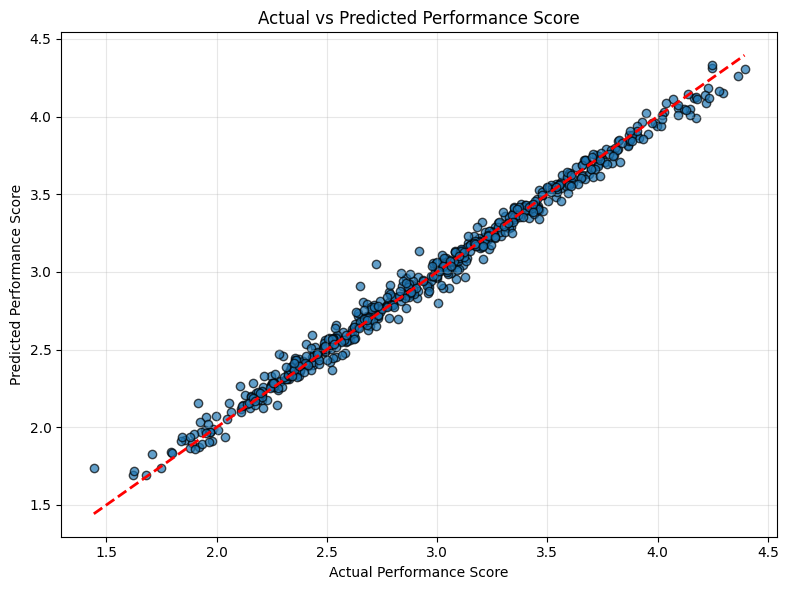

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.7, edgecolor='k')

# Perfect prediction reference line (y = x)
line_min = min(y_test.min(), pred.min())
line_max = max(y_test.max(), pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)

plt.xlabel('Actual Performance Score')
plt.ylabel('Predicted Performance Score')
plt.title('Actual vs Predicted Performance Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()